In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Load

In [2]:
df = pd.read_csv("Delhi metro.csv")
df.head()

,ID (Station ID),Station Names,Dist. From First Station(km),Metro Line,Opened(Year),Layout,Latitude,Longitude
0,1,Shaheed Sthal(First Station),0.0,Red line,08-03-2019,Elevated,28.670611,77.415582
1,2,Hindon River,1.0,Red line,08-03-2019,Elevated,28.878965,77.415483
2,3,Arthala,2.5,Red line,08-03-2019,Elevated,28.676999,77.391892
3,4,Mohan Nagar,3.2,Red line,08-03-2019,Elevated,28.606319,77.106082
4,5,Shyam park,4.5,Red line,08-03-2019,Elevated,28.698807,28.698807


## Data Clean

In [3]:
df.shape

(285, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID (Station ID)               285 non-null    int64  
 1   Station Names                 285 non-null    object 
 2   Dist. From First Station(km)  285 non-null    float64
 3   Metro Line                    285 non-null    object 
 4   Opened(Year)                  285 non-null    object 
 5   Layout                        285 non-null    object 
 6   Latitude                      285 non-null    float64
 7   Longitude                     285 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 17.9+ KB


In [5]:
df['Opened(Year)'] = df['Opened(Year)'].astype('datetime64[ns]')
df['Year'] = df['Opened(Year)'].dt.year
df.dtypes

ID (Station ID)                          int64
Station Names                           object
Dist. From First Station(km)           float64
Metro Line                              object
Opened(Year)                    datetime64[ns]
Layout                                  object
Latitude                               float64
Longitude                              float64
Year                                     int32
dtype: object

In [6]:
df.isnull().sum()

ID (Station ID)                 0
Station Names                   0
Dist. From First Station(km)    0
Metro Line                      0
Opened(Year)                    0
Layout                          0
Latitude                        0
Longitude                       0
Year                            0
dtype: int64

## Metro Network & Infrastructure 

How many stations exist on each metro line?

In [8]:
Total_stations = df.groupby('Metro Line')['Station Names'].count().reset_index().sort_values(by='Station Names',ascending=False)
Total_stations.rename(columns={'Station Names':'Total Stations'})

,Metro Line,Total Stations
1,Blue line,49
8,Pink line,38
12,Yellow line,37
11,Voilet line,34
10,Red line,29
6,Magenta line,25
0,Aqua line,21
4,Green line,21
9,Rapid Metro,11
2,Blue line branch,8


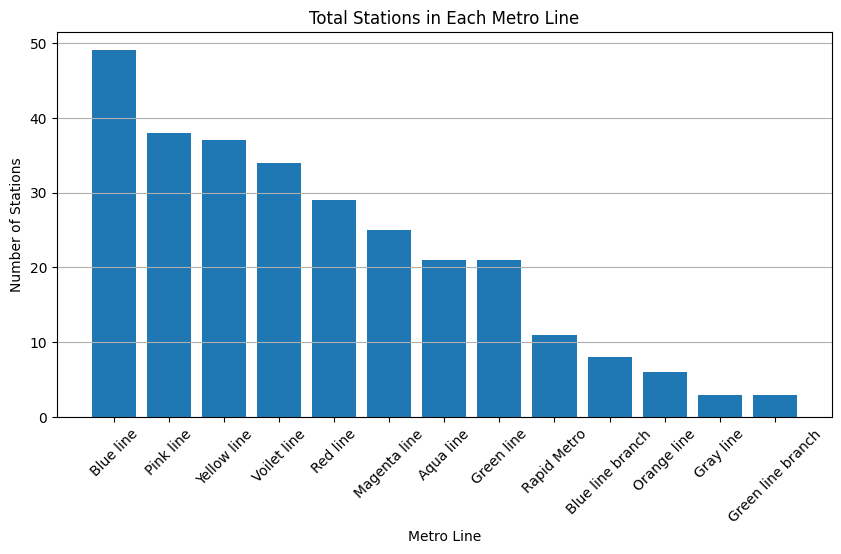

'Blue Line has the highest number of stations,\nwhile branch and smaller lines like the Gray Line and Green Line branch have the fewest, indicating uneven station distribution across metro lines.'

In [37]:
plt.figure(figsize=(10,5))

plt.bar(Total_stations['Metro Line'], Total_stations['Station Names'])

plt.title("Total Stations in Each Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Number of Stations")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

'''Blue Line has the highest number of stations,
while branch and smaller lines like the Gray Line and Green Line branch have the fewest, indicating uneven station distribution across metro lines.'''

What is the total length (in km) covered by each metro line? 

In [39]:
Total_length = df.groupby('Metro Line')['Dist. From First Station(km)'].max().sort_values().reset_index()
Total_length.rename(columns={'Dist. From First Station(km)':'Total Length (km)'},inplace=True)
Total_length

,Metro Line,Total Length (km)
0,Green line branch,2.1
1,Gray line,3.9
2,Blue line branch,8.1
3,Rapid Metro,10.0
4,Orange line,20.8
5,Green line,24.8
6,Aqua line,27.1
7,Red line,32.7
8,Magenta line,33.1
9,Voilet line,43.5


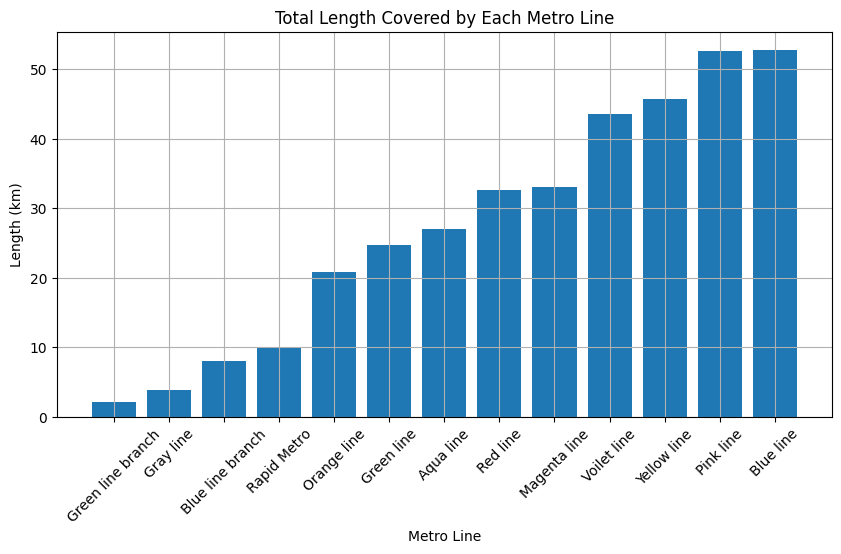

'Blue and Pink Lines cover the longest distances, while branch and smaller lines like the Green Line branch and Gray Line cover the shortest,\nhighlighting uneven network coverage.'

In [41]:
plt.figure(figsize=(10,5))
plt.bar(Total_length['Metro Line'], Total_length['Total Length (km)'])
plt.xticks(rotation=45)
plt.title("Total Length Covered by Each Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Length (km)")
plt.grid()

plt.show()

'''Blue and Pink Lines cover the longest distances, while branch and smaller lines like the Green Line branch and Gray Line cover the shortest,
highlighting uneven network coverage.'''

 Which metro line has the longest and shortest average distance between stations?

In [12]:
df['Interstation Distance'] = df.groupby('Metro Line')['Dist. From First Station(km)'].diff()

In [13]:
avg_dist = df.groupby('Metro Line')['Interstation Distance'].mean().reset_index()
avg_dist = avg_dist.sort_values(by='Interstation Distance', ascending=False)

avg_dist

,Metro Line,Interstation Distance
7,Orange line,4.160000
3,Gray line,1.950000
8,Pink line,1.421622
6,Magenta line,1.379167
0,Aqua line,1.355000
11,Voilet line,1.318182
12,Yellow line,1.269444
4,Green line,1.240000
10,Red line,1.167857
2,Blue line branch,1.157143


In [14]:
longest = avg_dist.loc[avg_dist['Interstation Distance'].idxmax()]
shortest = avg_dist.loc[avg_dist['Interstation Distance'].idxmin()]

In [15]:
display(longest,"/n",shortest)

Metro Line               Orange line
Interstation Distance           4.16
Name: 7, dtype: object

'/n'

Metro Line               Rapid Metro
Interstation Distance            1.0
Name: 9, dtype: object

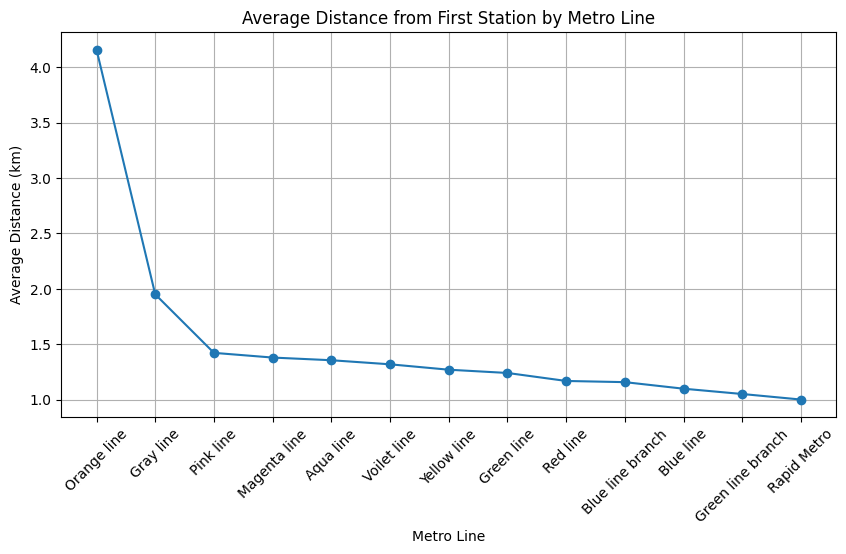

'Orange Line has the highest average distance from the first station, while Rapid Metro and branch lines have the lowest,\nindicating differences in how widely stations are spread across lines.'

In [42]:
plt.figure(figsize=(10,5))

plt.plot(avg_dist['Metro Line'], 
         avg_dist['Interstation Distance'], 
         marker='o')

plt.title("Average Distance from First Station by Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Average Distance (km)")

plt.xticks(rotation=45)
plt.grid()

plt.show()

'''Orange Line has the highest average distance from the first station, while Rapid Metro and branch lines have the lowest,
indicating differences in how widely stations are spread across lines.'''

What is the distribution of station layouts (underground, elevated, ground level) across all lines? 

In [17]:
Total_layouts = df['Layout'].value_counts().reset_index()
Total_layouts

,Layout,count
0,Elevated,214
1,Underground,68
2,At-Grade,3


How has the Delhi Metro network expanded year by year?

In [18]:
yearly_growth = df.groupby('Year')['Dist. From First Station(km)'].max().reset_index()
yearly_growth

,Year,Dist. From First Station(km)
0,2002,19.7
1,2003,24.3
2,2004,32.7
3,2005,30.8
4,2006,33.4
5,2008,11.4
6,2009,47.2
7,2010,45.7
8,2011,26.3
9,2013,10.0


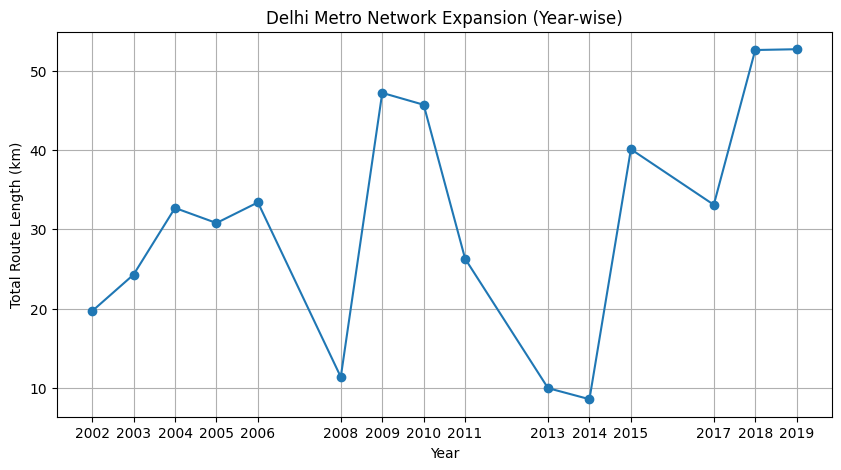

'Delhi Metro expansion has been uneven over the years,\nwith rapid growth in some periods (like 2009 and 2018–19) and slow or minimal expansion in others.'

In [43]:
plt.figure(figsize=(10,5))
plt.plot(yearly_growth['Year'], yearly_growth['Dist. From First Station(km)'], marker='o')

plt.title("Delhi Metro Network Expansion (Year-wise)")
plt.xlabel("Year")
plt.ylabel("Total Route Length (km)")

# Force integer values (no decimals)
plt.xticks(yearly_growth['Year'].astype(int))

plt.grid()
plt.show()

# 2007, 2012, 2016 missing which means the station had no activity those years.
'''Delhi Metro expansion has been uneven over the years,
with rapid growth in some periods (like 2009 and 2018–19) and slow or minimal expansion in others.'''

## Temporal Expansion & Trends

In which year did the most metro stations open?

In [20]:
stations_count = df.groupby('Year')['Station Names'].count().reset_index()
stations_count.rename(columns={'Stations Names':'Total Station'})
stations_count

,Year,Station Names
0,2002,6
1,2003,4
2,2004,11
3,2005,28
4,2006,9
5,2008,3
6,2009,17
7,2010,54
8,2011,13
9,2013,5


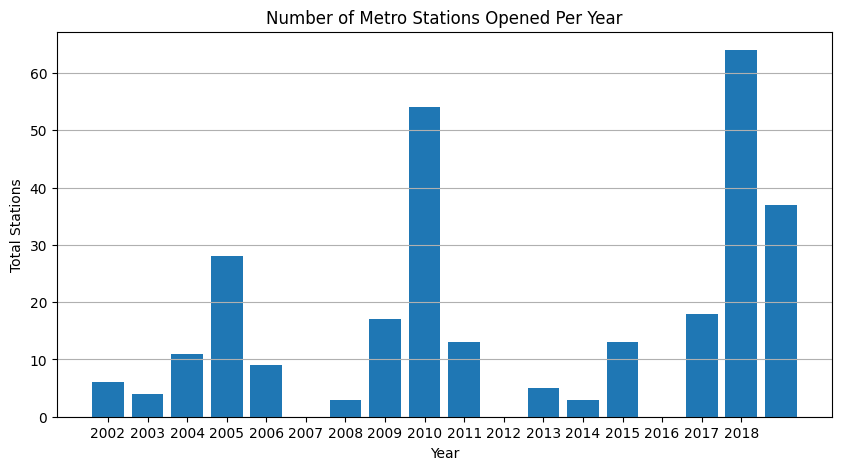

'the number of metro stations opened each year varies significantly,\nwith peak expansions around 2010 and 2018, indicating phases of rapid development.'

In [44]:
stations_count['Year'] = stations_count['Year'].astype(int)

plt.figure(figsize=(10,5))
plt.bar(stations_count['Year'], stations_count['Station Names'])

plt.title("Number of Metro Stations Opened Per Year")
plt.xlabel("Year")
plt.ylabel("Total Stations")

# Show years with gap (no decimals)
plt.xticks(np.arange(stations_count['Year'].min(),
                     stations_count['Year'].max()))

plt.grid(axis='y')
plt.show()

'''the number of metro stations opened each year varies significantly,
with peak expansions around 2010 and 2018, indicating phases of rapid development.'''

What is the trend of station openings per year across different lines? 

In [22]:
trend = df.groupby(['Metro Line','Year'])['Station Names'].count().sort_values(ascending=True).reset_index()
trend = trend.rename(columns={'Station Names':'Total Stations'})
trend.sort_values(by='Year')

,Metro Line,Year,Total Stations
21,Red line,2002,6
15,Red line,2003,4
25,Red line,2004,7
13,Yellow line,2004,4
23,Yellow line,2005,6
36,Blue line,2005,22
28,Blue line,2006,9
10,Red line,2008,3
30,Blue line,2009,11
20,Yellow line,2009,5


In [23]:
trend_pivot = trend.pivot(index='Year', columns='Metro Line', values='Total Stations').fillna(0)

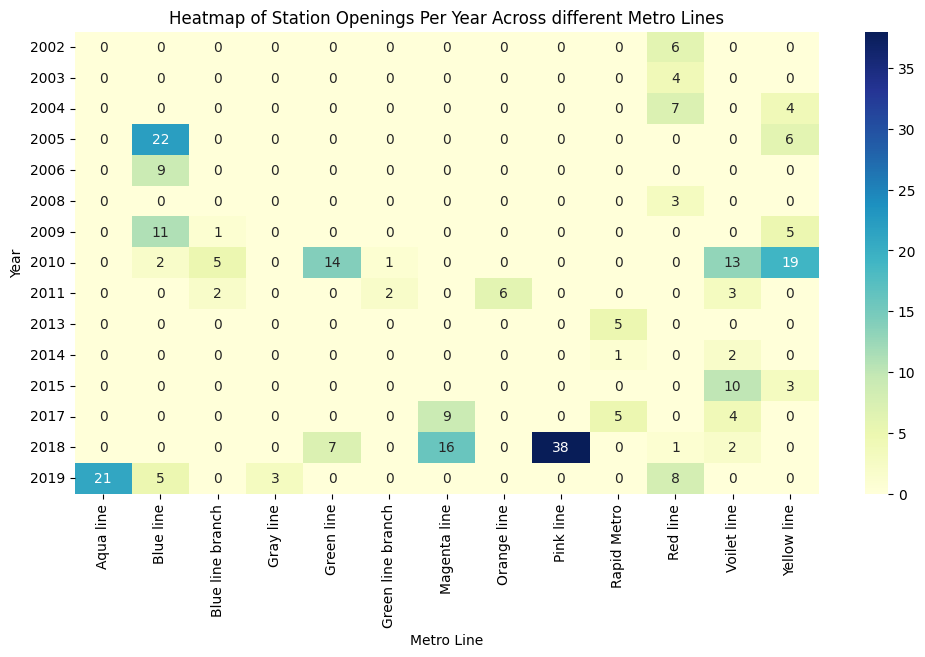

In [24]:
heatmap_data = trend.pivot(index='Year', columns='Metro Line', values='Total Stations').fillna(0)

# Ensure Year is integer
heatmap_data.index = heatmap_data.index.astype(int)

# Step 3: Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')

plt.title("Heatmap of Station Openings Per Year Across different Metro Lines")
plt.xlabel("Metro Line")
plt.ylabel("Year")

plt.show()

Are newer stations more likely to be underground or elevated?

In [25]:
df['Year'] = df['Opened(Year)'].dt.year

df['Era'] = df['Year'].apply(lambda x: 'New' if x >= 2010 else 'Old')

In [26]:
result = df.groupby(['Era', 'Layout']).size().unstack(fill_value=0)
display(result)

Layout,At-Grade,Elevated,Underground
Era,,,
New,1,152,54
Old,2,62,14


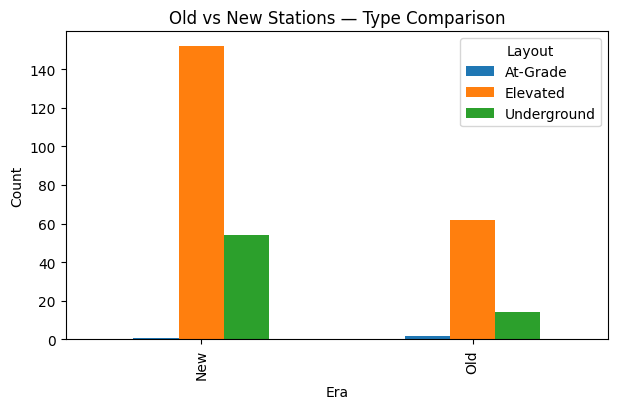

In [27]:
result.plot(kind='bar', figsize=(7,4))
plt.title("Old vs New Stations — Type Comparison")
plt.ylabel("Count")
plt.show()

#Newer stations are more likely to be Elevated
#New stations have ~150 Elevated vs ~55 Underground — Elevated dominates heavily
#Even in Old stations, Elevated (~62) was more common than Underground (~15)
#So Elevated has always been preferred, but the gap is much larger in newer stations

## Accessibility & Planning

 Which metro stations are the farthest from the first station in each line?

In [28]:
farthest_stations = df.loc[df.groupby('Metro Line')['Dist. From First Station(km)'].idxmax()
][['Metro Line', 'Station Names', 'Dist. From First Station(km)']]

farthest_stations = farthest_stations.sort_values(by='Dist. From First Station(km)', ascending=False)
farthest_stations

,Metro Line,Station Names,Dist. From First Station(km)
114,Blue line,Noida Sector 62,52.7
254,Pink line,Shiv Vihar,52.6
65,Yellow line,Huda City Centre,45.7
191,Voilet line,Raja Nahar Singh,43.5
216,Magenta line,Botanical Garden [Conn: Blue],33.1
28,Red line,Rithala(last station),32.7
275,Aqua line,Depot Greater Noida,27.1
146,Green line,Brigadier Hoshiar Singh,24.8
284,Orange line,Dwarka Sector 21 [Conn: Blue],20.8
157,Rapid Metro,DLF Phase 3,10.0


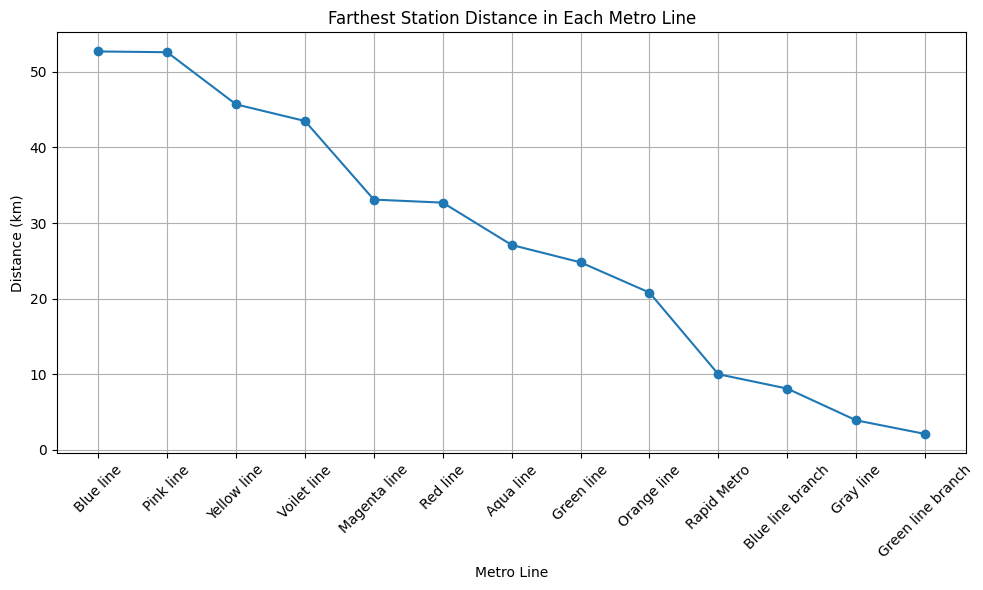

'Blue and Pink lines have the longest reach (farthest stations),\nwhile branch and smaller lines like the Green Line branch and Gray line cover the shortest distances.'

In [29]:
plt.figure(figsize=(10,6))

plt.plot(farthest_stations['Metro Line'],
         farthest_stations['Dist. From First Station(km)'],
         marker='o')

plt.xticks(rotation=45)
plt.xlabel('Metro Line')
plt.ylabel('Distance (km)')
plt.title('Farthest Station Distance in Each Metro Line')

plt.grid(True)
plt.tight_layout()
plt.show()

'''Blue and Pink lines have the longest reach (farthest stations),
while branch and smaller lines like the Green Line branch and Gray line cover the shortest distances.'''

Are some lines disproportionately serving specific parts of the city?

In [30]:
analysis = df.groupby('Metro Line').agg({
    'Station Names': 'count',
    'Dist. From First Station(km)': 'max'
}).reset_index()

analysis.rename(columns={
    'Station Names': 'Total Stations',
    'Dist. From First Station(km)': 'Total Length (km)'
}, inplace=True)

analysis = analysis.sort_values(by='Total Length (km)', ascending=False)
analysis

,Metro Line,Total Stations,Total Length (km)
1,Blue line,49,52.7
8,Pink line,38,52.6
12,Yellow line,37,45.7
11,Voilet line,34,43.5
6,Magenta line,25,33.1
10,Red line,29,32.7
0,Aqua line,21,27.1
4,Green line,21,24.8
7,Orange line,6,20.8
9,Rapid Metro,11,10.0


In [31]:
analysis['km_per_station'] = analysis['Total Length (km)'] / analysis['Total Stations']
np.round(analysis,1)

,Metro Line,Total Stations,Total Length (km),km_per_station
1,Blue line,49,52.7,1.1
8,Pink line,38,52.6,1.4
12,Yellow line,37,45.7,1.2
11,Voilet line,34,43.5,1.3
6,Magenta line,25,33.1,1.3
10,Red line,29,32.7,1.1
0,Aqua line,21,27.1,1.3
4,Green line,21,24.8,1.2
7,Orange line,6,20.8,3.5
9,Rapid Metro,11,10.0,0.9


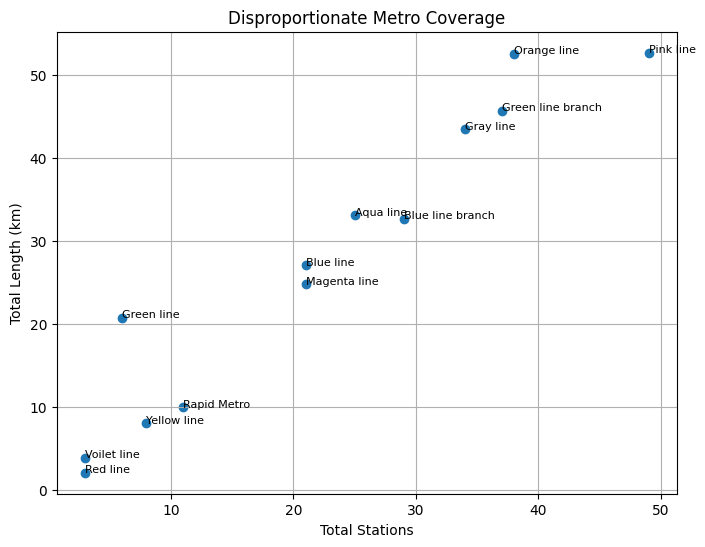

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(analysis['Total Stations'],
            analysis['Total Length (km)'])

for i, txt in enumerate(analysis['Metro Line']):
    plt.annotate(txt,
                 (analysis['Total Stations'][i],
                  analysis['Total Length (km)'][i]),
                 fontsize=8)

plt.xlabel('Total Stations')
plt.ylabel('Total Length (km)')
plt.title('Disproportionate Metro Coverage')

plt.grid(True)
plt.show()

## KPI & Performance Indicators

 What are the key performance metrics for each line (e.g., stations per km, avg interstation 
distance)? 

In [33]:
analysis = df.groupby('Metro Line').agg({
    'Station Names': 'count',
    'Dist. From First Station(km)': 'max'
}).reset_index()

analysis.rename(columns={
    'Station Names': 'Total Stations',
    'Dist. From First Station(km)': 'Total Length (km)'
}, inplace=True)

# Stations per km (density)
analysis['Stations per km'] = analysis['Total Stations'] / analysis['Total Length (km)']

# Average interstation distance
analysis['Avg Interstation Distance (km)'] = analysis['Total Length (km)'] / (analysis['Total Stations'] - 1)

analysis = analysis.sort_values(by='Total Length (km)', ascending=False)

np.round(analysis,1)

,Metro Line,Total Stations,Total Length (km),Stations per km,Avg Interstation Distance (km)
1,Blue line,49,52.7,0.9,1.1
8,Pink line,38,52.6,0.7,1.4
12,Yellow line,37,45.7,0.8,1.3
11,Voilet line,34,43.5,0.8,1.3
6,Magenta line,25,33.1,0.8,1.4
10,Red line,29,32.7,0.9,1.2
0,Aqua line,21,27.1,0.8,1.4
4,Green line,21,24.8,0.8,1.2
7,Orange line,6,20.8,0.3,4.2
9,Rapid Metro,11,10.0,1.1,1.0


How does the infrastructure type vary by line or year of launch?

In [34]:
infra_line = df.groupby(['Metro Line', 'Layout']).size().reset_index(name='Count').sort_values(by='Count')

infra_line

,Metro Line,Layout,Count
1,Blue line,At-Grade,1
4,Blue line branch,At-Grade,1
7,Gray line,Underground,1
9,Green line branch,At-Grade,1
13,Orange line,Elevated,1
10,Green line branch,Elevated,2
6,Gray line,Elevated,2
3,Blue line,Underground,4
14,Orange line,Underground,5
5,Blue line branch,Elevated,7


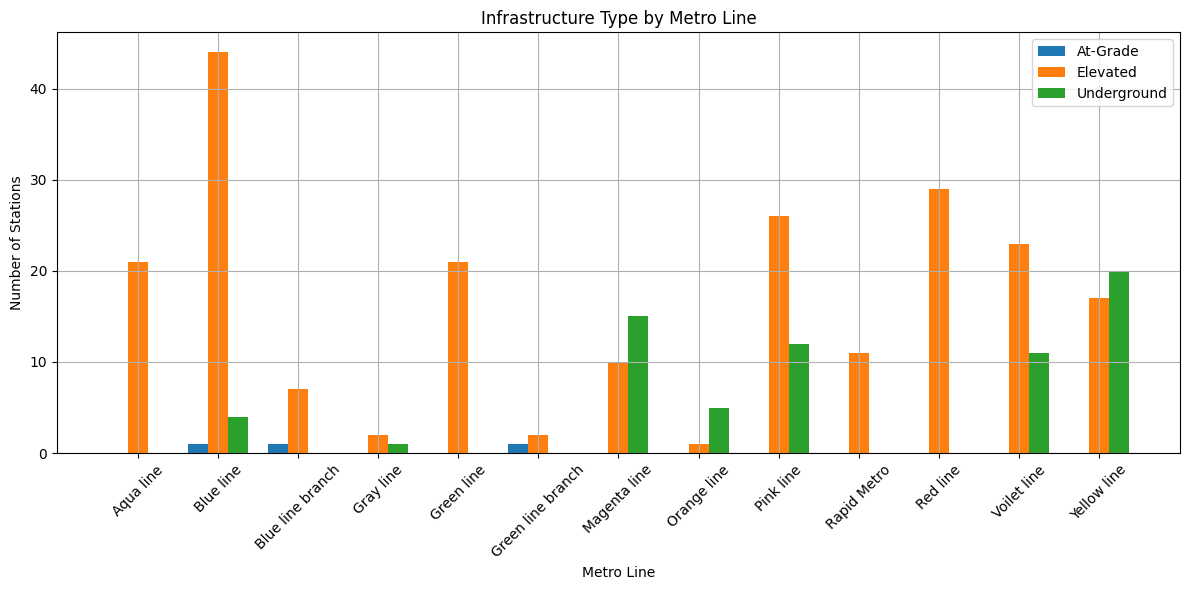

In [35]:
infra_line = df.groupby(['Metro Line', 'Layout']).size().unstack().fillna(0)

x = np.arange(len(infra_line.index))
width = 0.25

plt.figure(figsize=(12,6))

for i, col in enumerate(infra_line.columns):
    plt.bar(x + i*width, infra_line[col], width, label=col)

plt.xticks(x + width, infra_line.index, rotation=45)
plt.xlabel('Metro Line')
plt.ylabel('Number of Stations')
plt.title('Infrastructure Type by Metro Line')

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

 Can we identify underserved areas that need new stations? 

In [36]:
df = df.sort_values(['Metro Line', 'Dist. From First Station(km)'])

df['Interstation Distance'] = df.groupby('Metro Line')['Dist. From First Station(km)'].diff()

# Find unusually large gaps
gaps = df[df['Interstation Distance'] > df['Interstation Distance'].mean()]

gaps[['Metro Line', 'Station Names', 'Interstation Distance']]

,Metro Line,Station Names,Interstation Distance
260,Aqua line,NSEZ Noida,2.0
262,Aqua line,Noida Sector 137,1.5
263,Aqua line,Noida Sector 142,1.6
265,Aqua line,Noida Sector 144,1.4
267,Aqua line,Noida Sector 146,1.7
...,...,...,...
56,Yellow line,Qutab Minar,1.7
58,Yellow line,Sultanpur,1.6
60,Yellow line,Arjan Garh,2.7
61,Yellow line,Guru Dronacharya,2.3
